# predict DD

In [1]:
# import merged csv

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


df = pd.read_csv("../data/wide_diff_all_data.csv")



In [4]:
unique_age_strings = sorted(df["age_group"].dropna().astype(str).unique())
print(unique_age_strings)

['22-25', '26-30', '31-35', '36+']


In [5]:
count_36_plus = (df["age_group"] == "36+").sum()
print(count_36_plus)

7


In [6]:
age_map = {
    "22-25": 23.5,
    "26-30": 28,
    "31-35": 33,
    "36+": 38
}

df["age_average"] = df["age_group"].map(age_map)

In [7]:
df["age_average"] = pd.to_numeric(df["age_average"], errors="coerce")


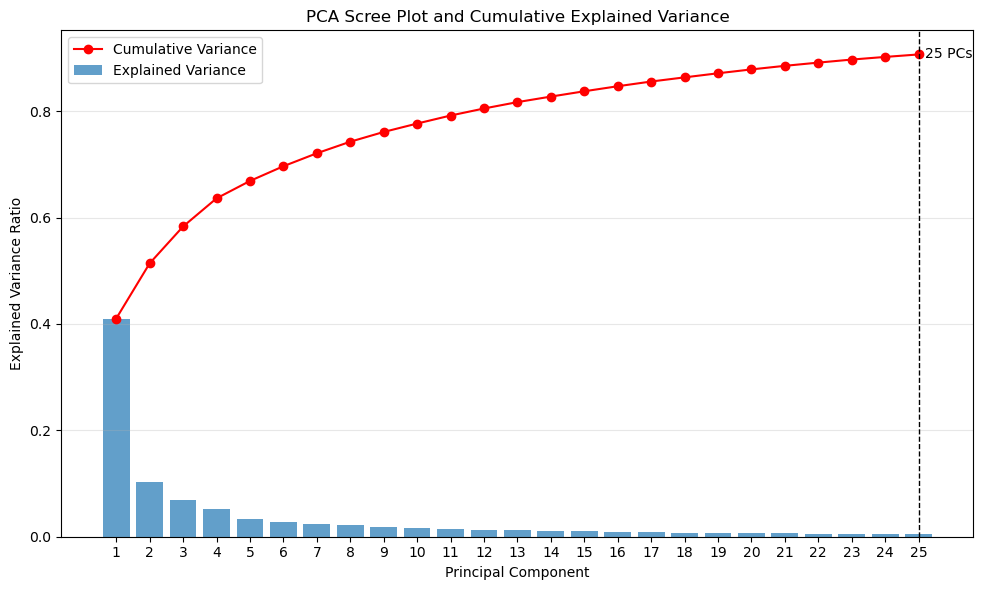

In [8]:


pc_substrings = ["dki_fa", "dki_md", "dki_mk", "dki_awf"]

diffusion_cols = [
    col for col in df.columns
    if any(sub in col for sub in pc_substrings)
]

X = df[diffusion_cols].copy()
X = X.apply(pd.to_numeric, errors="coerce").fillna(X.mean())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=25, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(25)],
    index=df.index
)

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(25)],
    "ExplainedVariance": pca.explained_variance_ratio_,
    "CumulativeVariance": pca.explained_variance_ratio_.cumsum()
})

explained_variance

# Explained variance table
explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(25)],
    "ExplainedVariance": pca.explained_variance_ratio_,
    "CumulativeVariance": pca.explained_variance_ratio_.cumsum()
})

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

pcs = range(1, 26)

# Scree bars
ax.bar(
    pcs,
    explained_variance["ExplainedVariance"],
    alpha=0.7,
    label="Explained Variance"
)

# Cumulative line
ax.plot(
    pcs,
    explained_variance["CumulativeVariance"],
    marker="o",
    color="red",
    label="Cumulative Variance"
)

# Mark 25 PCs
ax.axvline(25, color="black", linestyle="--", linewidth=1)
ax.text(25.2, explained_variance["CumulativeVariance"].iloc[-1], "25 PCs", va="center")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Scree Plot and Cumulative Explained Variance")
ax.set_xticks(pcs)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Final proper CV and TEST

## Final model results - re-adjusting on whole train set - testing on test set

In [14]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error

train_df = df.copy()
test_df = pd.read_csv("../data/test_wide_diff_all_data.csv")

# ----------------------------
# 1) Build raw feature matrices
# ----------------------------
diffusion_cols = [col for col in train_df.columns if "dki_" in col]

X_train = train_df[diffusion_cols].copy()
X_test = test_df[diffusion_cols].copy()

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

y_train = pd.to_numeric(train_df["DDisc_AUC_40K"], errors="coerce")
y_test = pd.to_numeric(test_df["DDisc_AUC_40K"], errors="coerce")

train_mask = y_train.notna() & X_train.notna().all(axis=1)
test_mask = y_test.notna() & X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# ----------------------------
# 2) Pipeline: PCA inside folds
# ----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", Ridge())
])

param_grid = {
    "pca__n_components": [5, 10, 15, 20, 25],
    "model__alpha": np.logspace(-3, 3, 25)
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    refit=True
)

# ----------------------------
# 3) Nested CV on training set
# ----------------------------
nested = cross_validate(
    search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=("r2", "neg_root_mean_squared_error"),
    return_estimator=True,
    n_jobs=-1
)

print("Nested CV fold results:")
for i, est in enumerate(nested["estimator"], start=1):
    print(f"Fold {i}:")
    print(f"  best params: {est.best_params_}")
    print(f"  best inner-CV score: {est.best_score_:.6f}")

print(f"\nMean nested CV R2: {nested['test_r2'].mean():.4f} ± {nested['test_r2'].std():.4f}")
print(f"Mean nested CV RMSE: {-nested['test_neg_root_mean_squared_error'].mean():.4f} ± {nested['test_neg_root_mean_squared_error'].std():.4f}")

# ----------------------------
# 4) Fit final model on all training data
# ----------------------------
search.fit(X_train, y_train)

print("\nBest overall parameters on full training set:")
print(search.best_params_)

best_model = search.best_estimator_
best_pca = best_model.named_steps["pca"]
best_ridge = best_model.named_steps["model"]

# Ridge weights are on PCA components, not original diffusion features
pca_weight_summary = pd.DataFrame({
    "feature": [f"PC{i+1}" for i in range(len(best_ridge.coef_))],
    "weight": best_ridge.coef_
})
pca_weight_summary["abs_weight"] = pca_weight_summary["weight"].abs()
pca_weight_summary = pca_weight_summary.sort_values("abs_weight", ascending=False)

print("\nTop PCA component weights:")
print(pca_weight_summary.head(20).to_string(index=False, float_format=lambda x: f"{x:.10f}"))

# ----------------------------
# 5) Evaluate once on held-out test set
# ----------------------------
y_pred = search.predict(X_test)

print(f"\nTest R2: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Train shape: (691, 96) (691,)
Test shape: (173, 96) (173,)
Nested CV fold results:
Fold 1:
  best params: {'model__alpha': 316.2277660168379, 'pca__n_components': 25}
  best inner-CV score: -0.076036
Fold 2:
  best params: {'model__alpha': 1000.0, 'pca__n_components': 25}
  best inner-CV score: -0.077931
Fold 3:
  best params: {'model__alpha': 562.341325190349, 'pca__n_components': 25}
  best inner-CV score: -0.079591
Fold 4:
  best params: {'model__alpha': 316.2277660168379, 'pca__n_components': 20}
  best inner-CV score: -0.081929
Fold 5:
  best params: {'model__alpha': 562.341325190349, 'pca__n_components': 20}
  best inner-CV score: -0.081611

Mean nested CV R2: -0.0281 ± 0.0308
Mean nested CV RMSE: 0.2845 ± 0.0144

Best overall parameters on full training set:
{'model__alpha': 1000.0, 'pca__n_components': 25}

Top PCA component weights:
feature        weight   abs_weight
    PC8  0.0118954182 0.0118954182
   PC15  0.0105934972 0.0105934972
    PC9 -0.0101721676 0.0101721676
   PC1

## Plotting results

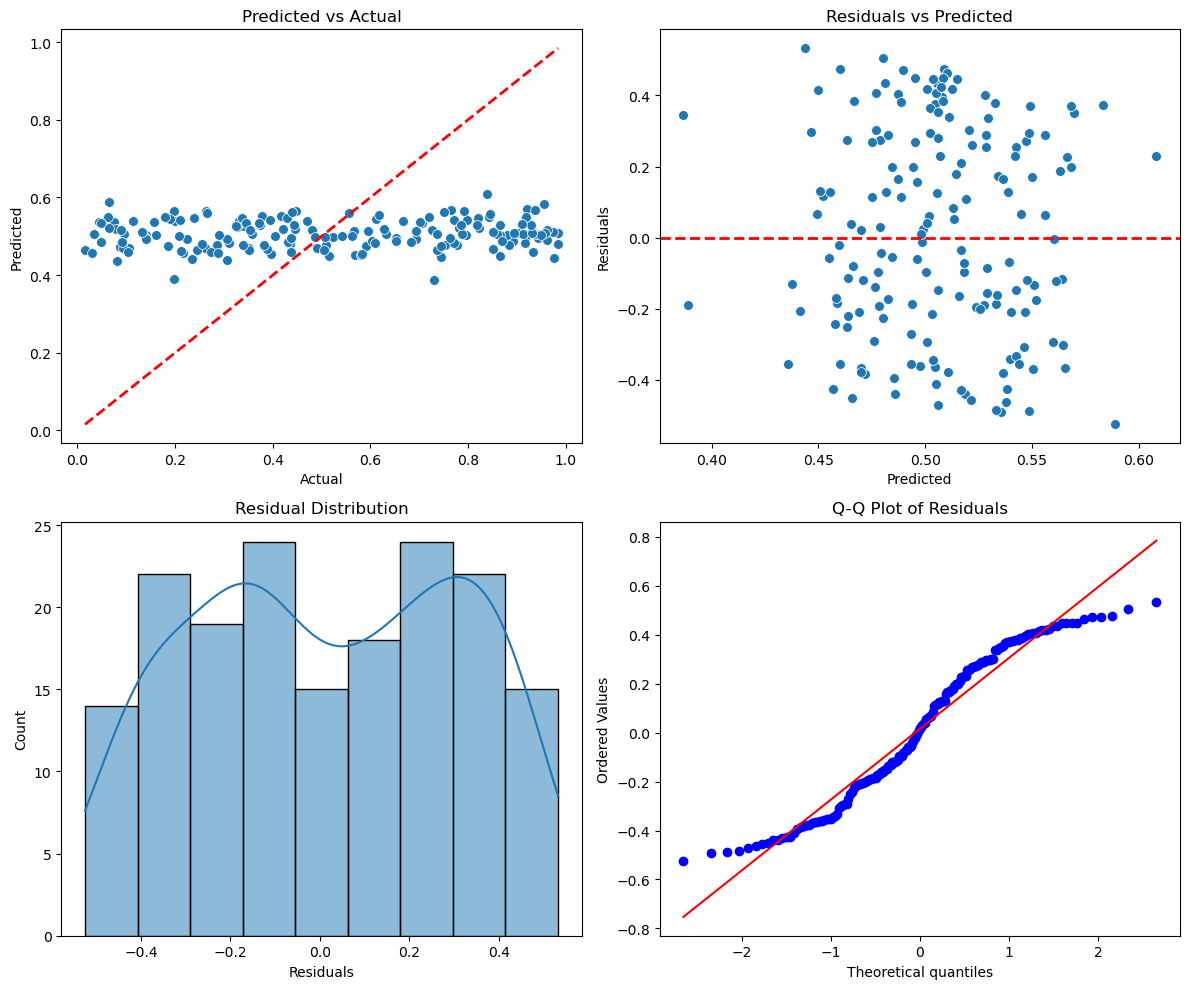

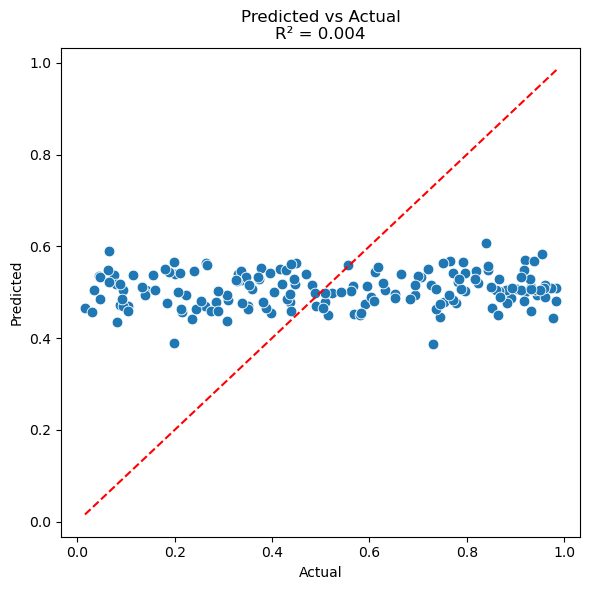

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Residuals
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0, 0], s=50)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Predicted vs Actual")

# 2) Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 1], s=50)
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs Predicted")

# 3) Residual histogram
sns.histplot(residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_title("Residual Distribution")

# 4) Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual\nR² = {r2_score(y_test, y_pred):.3f}")
plt.tight_layout()
plt.show()

## attempt at boothstraping model feature weights

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bootstrap_ridge_pca_weights(
    X_train,
    y_train,
    n_bootstrap=500,
    n_components=25,
    alpha=1.0,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    boot_rows = []
    feature_names = [f"PC{i+1}" for i in range(n_components)]

    for b in range(n_bootstrap):
        sample_idx = rng.choice(
            np.arange(len(X_train)),
            size=len(X_train),
            replace=True,
        )

        X_boot = X_train.iloc[sample_idx].copy()
        y_boot = y_train.iloc[sample_idx].copy()

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=random_state)),
            ("model", Ridge(alpha=alpha)),
        ])

        pipe.fit(X_boot, y_boot)

        coefs = pipe.named_steps["model"].coef_
        for feature, weight in zip(feature_names, coefs):
            boot_rows.append({
                "bootstrap_id": b,
                "feature": feature,
                "weight": weight,
            })

    feature_weights = pd.DataFrame(boot_rows)

    feature_weights_summary = (
        feature_weights.groupby("feature")["weight"]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
        .sort_values("mean", key=lambda s: s.abs(), ascending=False)
    )

    alpha_level = 0.05
    lower_q = 100 * (alpha_level / 2)
    upper_q = 100 * (1 - alpha_level / 2)

    ci_rows = (
        feature_weights.groupby("feature")["weight"]
        .agg(
            bootstrap_ci_low=lambda s: np.percentile(s, lower_q),
            bootstrap_ci_high=lambda s: np.percentile(s, upper_q),
        )
        .reset_index()
    )

    feature_weights_summary = feature_weights_summary.merge(
        ci_rows,
        on="feature",
        how="left",
    )

    return feature_weights, feature_weights_summary

feature          mean          std           min          max  bootstrap_ci_low  bootstrap_ci_high
    PC8  0.0152262695 0.0123194346 -0.0319790425 0.0391485478     -0.0165489928       0.0344933262
    PC5  0.0079493018 0.0064020362 -0.0211203931 0.0244698721     -0.0040257952       0.0206377406
   PC19  0.0060414638 0.0230483476 -0.0663617758 0.0667456241     -0.0402092161       0.0468373867
    PC7  0.0054742118 0.0101385153 -0.0257501011 0.0345131167     -0.0155741259       0.0254193383
   PC12  0.0051477801 0.0149699319 -0.0377426785 0.0472730945     -0.0255240912       0.0327952634
   PC15  0.0045205953 0.0214741103 -0.0516654673 0.0573953155     -0.0365943902       0.0438481471
   PC18  0.0038398154 0.0231298192 -0.0685590860 0.0648371909     -0.0395977823       0.0443955409
    PC4 -0.0035090379 0.0051970515 -0.0178689576 0.0154351817     -0.0129744300       0.0067153474
   PC16  0.0032822755 0.0212767358 -0.0539762871 0.0612392585     -0.0385816875       0.0427492060
   PC23 -0

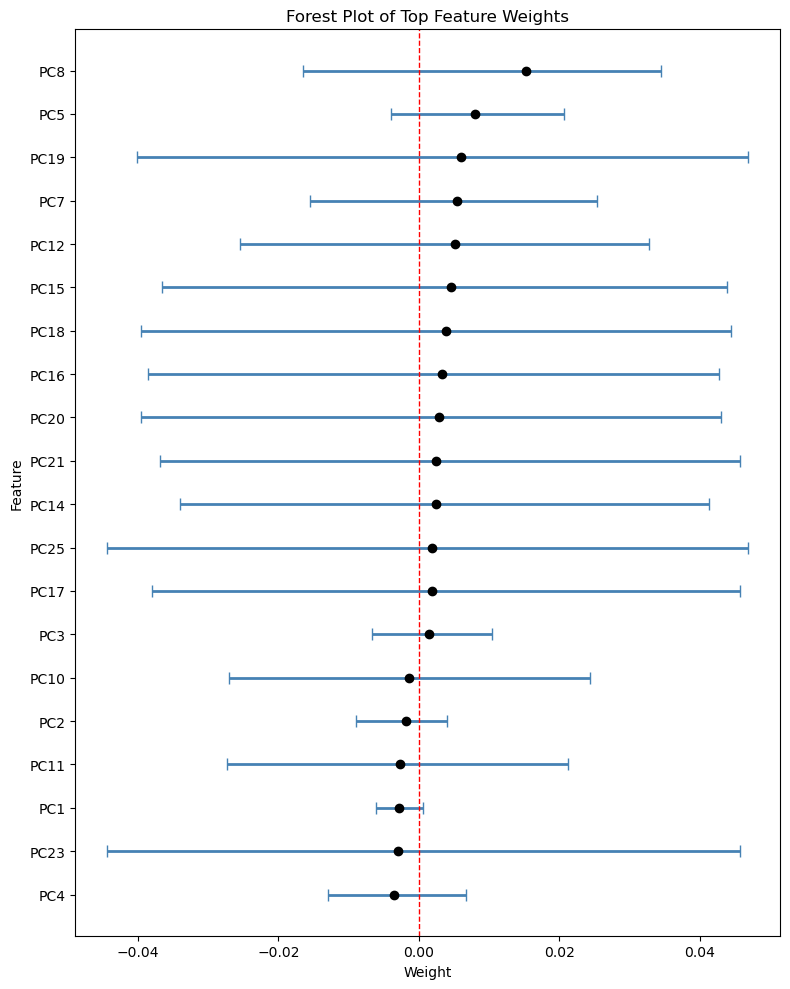

In [18]:
train_df = df.copy()
test_df = pd.read_csv("../data/test_wide_diff_all_data.csv")

diffusion_cols = [col for col in train_df.columns if "dki_" in col]

X_train = train_df[diffusion_cols].apply(pd.to_numeric, errors="coerce")
y_train = pd.to_numeric(train_df["DDisc_AUC_40K"], errors="coerce")

train_mask = y_train.notna() & X_train.notna().all(axis=1)
X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

feature_weights, feature_weights_summary = bootstrap_ridge_pca_weights(
    X_train=X_train,
    y_train=y_train,
    n_bootstrap=500,
    n_components=25,
    alpha=1.0,
    random_state=42,
)

print(feature_weights_summary.head(20).to_string(index=False, float_format=lambda x: f"{x:.10f}"))

plot_df = (
    feature_weights_summary
    .sort_values("mean", key=lambda s: s.abs(), ascending=False)
    .head(20)
    .copy()
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(8, 10))

ax.errorbar(
    x=plot_df["mean"],
    y=plot_df["feature"],
    xerr=[
        plot_df["mean"] - plot_df["bootstrap_ci_low"],
        plot_df["bootstrap_ci_high"] - plot_df["mean"],
    ],
    fmt="o",
    color="black",
    ecolor="steelblue",
    elinewidth=2,
    capsize=4,
)

ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Weight")
ax.set_ylabel("Feature")
ax.set_title("Forest Plot of Top Feature Weights")

plt.tight_layout()
plt.show()

# Predict age - double check model validity

# other models 

In [19]:
from trois_utilities import run_nested_cv_regression
from trois_utilities import run_diffusion_pca
ridge_results = run_nested_cv_regression(df, run_diffusion_pca(df, n_pcs=25)["pca_df"], model_name="ridge",use_age_average=True)

print(f"Mean nested CV R2: {ridge_results['mean_r2']:.4f} ± {ridge_results['sd_r2']:.4f}")
print(f"Mean nested CV RMSE: {ridge_results['mean_rmse']:.4f} ± {ridge_results['sd_rmse']:.4f}")

ridge_results["feature_weights_summary"].head(20)

Mean nested CV R2: -0.0192 ± 0.0287
Mean nested CV RMSE: 0.2834 ± 0.0173


,feature,mean,std,min,max,bootstrap_mean,bootstrap_ci_low,bootstrap_ci_high
0,PC8,0.014854,0.006091,0.006865,0.022765,0.014915,0.010045,0.019458
1,PC15,0.013424,0.005486,0.006300,0.020284,0.013448,0.009094,0.017451
2,PC18,-0.012034,0.005880,-0.021742,-0.006901,-0.011968,-0.017049,-0.008182
3,PC9,-0.011440,0.002749,-0.016110,-0.009495,-0.011441,-0.013911,-0.009773
4,PC22,0.010416,0.001667,0.008281,0.012295,0.010406,0.009181,0.011711
5,PC14,-0.009734,0.004169,-0.014074,-0.003542,-0.009729,-0.012745,-0.006427
6,PC1,-0.008900,0.005401,-0.014595,-0.002830,-0.008991,-0.013158,-0.004838
7,PC17,-0.008516,0.004580,-0.016259,-0.004196,-0.008541,-0.012594,-0.005530
8,PC19,0.008139,0.002859,0.003716,0.010694,0.008109,0.005618,0.010154
9,PC12,0.007876,0.004194,0.003293,0.014358,0.007881,0.004747,0.011575


In [20]:
# withouth age + sex
ridge_results = run_nested_cv_regression(
    df=df,
    pca_df=pca_df,
    task="regression",
    model_name="ridge",
    use_age_covariate=False,
    use_age_average=False,
    use_sex_covariate=False,
)

print(f"Mean nested CV R2: {ridge_results['mean_r2']:.4f} ± {ridge_results['sd_r2']:.4f}")
print(f"Mean nested CV RMSE: {ridge_results['mean_rmse']:.4f} ± {ridge_results['sd_rmse']:.4f}")

ridge_results["feature_weights_summary"].head(20)

Mean nested CV R2: -0.0175 ± 0.0278
Mean nested CV RMSE: 0.2831 ± 0.0174


,feature,mean,std,min,max,bootstrap_mean,bootstrap_ci_low,bootstrap_ci_high
0,PC8,0.014846,0.006237,0.006849,0.023293,0.014853,0.010313,0.019380
1,PC15,0.013299,0.005445,0.006221,0.020081,0.013269,0.008764,0.017285
2,PC18,-0.011919,0.005921,-0.021736,-0.006871,-0.011936,-0.017009,-0.008090
3,PC9,-0.011591,0.002993,-0.016726,-0.009583,-0.011627,-0.014362,-0.009814
4,PC22,0.010235,0.001668,0.008208,0.012290,0.010218,0.008977,0.011493
5,PC14,-0.009500,0.004072,-0.013501,-0.003406,-0.009504,-0.012435,-0.006306
6,PC1,-0.009109,0.005368,-0.014723,-0.002903,-0.009112,-0.013324,-0.004968
7,PC19,0.008437,0.002847,0.004094,0.010771,0.008412,0.006011,0.010406
8,PC17,-0.008351,0.004468,-0.015846,-0.003974,-0.008349,-0.012327,-0.005494
9,PC5,0.008246,0.004414,0.003534,0.013258,0.008258,0.004872,0.011620


## Other models - before settling on final model

In [21]:
feature_cols = [col for col in df.columns if "dki_" in col]
feature_df = df[feature_cols].copy()
feature_df = feature_df.apply(pd.to_numeric, errors="coerce")

In [22]:
elastic_results = run_nested_cv_regression(
    df=df,
    pca_df=feature_df,   # raw diffusion features instead of PCA
    model_name="elastic",
    use_age_covariate=False,
    use_age_average=False,
    use_sex_covariate=False,
)

print(f"Mean nested CV R2: {elastic_results['mean_r2']:.4f} ± {elastic_results['sd_r2']:.4f}")
print(f"Mean nested CV RMSE: {elastic_results['mean_rmse']:.4f} ± {elastic_results['sd_rmse']:.4f}")

elastic_results["feature_weights_summary"].head(50)

Mean nested CV R2: -0.0476 ± 0.0364
Mean nested CV RMSE: 0.2872 ± 0.0163


,feature,mean,std,min,max,bootstrap_mean,bootstrap_ci_low,bootstrap_ci_high
0,CST_L_dki_awf,0.013725,0.023058,0.000000,0.053205,0.013563,0.000000,0.035007
1,SupFrontal_dki_awf,-0.013550,0.020802,-0.047178,-0.000000,-0.013448,-0.032421,0.000000
2,SLF_R_dki_fa,0.008633,0.012163,0.000000,0.025629,0.008966,0.000000,0.018885
3,CST_R_dki_mk,-0.008223,0.011497,-0.023847,-0.000000,-0.008269,-0.017762,0.000000
4,SLF_L_dki_fa,0.007784,0.010702,-0.000000,0.020814,0.007768,0.000000,0.016110
5,CGC_L_dki_awf,-0.007476,0.013359,-0.030828,-0.000000,-0.007354,-0.019807,0.000000
6,Occipital_dki_md,0.006715,0.010151,0.000000,0.022872,0.006609,0.000000,0.013769
7,Orbital_dki_mk,0.006633,0.013169,0.000000,0.030067,0.006492,0.000000,0.018660
8,CST_L_dki_md,0.006190,0.013814,0.000000,0.030902,0.006178,0.000000,0.018551
9,Temporal_dki_mk,-0.005230,0.007161,-0.013113,-0.000000,-0.005217,-0.010475,0.000000


In [23]:
lasso_results = run_nested_cv_regression(df, pca_df, model_name="lasso")
print(f"Mean nested CV R2: {lasso_results['mean_r2']:.4f} ± {lasso_results['sd_r2']:.4f}")
print(f"Mean nested CV RMSE: {lasso_results['mean_rmse']:.4f} ± {lasso_results['sd_rmse']:.4f}")

Mean nested CV R2: -0.0363 ± 0.0342
Mean nested CV RMSE: 0.2857 ± 0.0172


In [24]:
linear_results = run_nested_cv_regression(df, pca_df, model_name="linear")
print(f"Mean nested CV R2: {linear_results['mean_r2']:.4f} ± {linear_results['sd_r2']:.4f}")
print(f"Mean nested CV RMSE: {linear_results['mean_rmse']:.4f} ± {linear_results['sd_rmse']:.4f}")

Mean nested CV R2: -0.0620 ± 0.0632
Mean nested CV RMSE: 0.2889 ± 0.0147


In [25]:
rf_results = run_nested_cv_regression(df, pca_df, model_name="rf")
print(f"RF R2: {rf_results['mean_r2']:.4f} ± {rf_results['sd_r2']:.4f}")
print(f"RF RMSE: {rf_results['mean_rmse']:.4f} ± {rf_results['sd_rmse']:.4f}")

KeyboardInterrupt: 

In [ ]:
rf_results["feature_weights_summary"].head(20)

In [27]:
svr_results = run_nested_cv_regression(df, pca_df, model_name="svr")
print(f"RF R2: {svr_results['mean_r2']:.4f} ± {svr_results['sd_r2']:.4f}")
print(f"RF RMSE: {svr_results['mean_rmse']:.4f} ± {svr_results['sd_rmse']:.4f}")

RF R2: -0.0281 ± 0.0354
RF RMSE: 0.2845 ± 0.0155


In [28]:
if svr_results["feature_weights_summary"] is not None:
    print(svr_results["feature_weights_summary"].head(20))
else:
    print("No native feature weights for this model (e.g., SVR with RBF).")

No native feature weights for this model (e.g., SVR with RBF).


In [29]:
age_results = run_nested_cv_regression(
    df,
    pca_df,   # or pca_df directly
    task="age_classification",
    model_name="logreg",        # logreg, rf, svc, knn
    include_sex_for_age=False,  # diffusion-only by default
)

print(f"Accuracy: {age_results['mean_accuracy']:.4f} ± {age_results['sd_accuracy']:.4f}")
print(f"Balanced Acc: {age_results['mean_balanced_accuracy']:.4f} ± {age_results['sd_balanced_accuracy']:.4f}")
print(f"F1 macro: {age_results['mean_f1_macro']:.4f} ± {age_results['sd_f1_macro']:.4f}")

age_results["feature_weights_summary"].head(20)

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWar

Accuracy: 0.3850 ± 0.0276
Balanced Acc: 0.3858 ± 0.1165
F1 macro: 0.3127 ± 0.0264


,feature,mean,std,min,max,bootstrap_mean,bootstrap_ci_low,bootstrap_ci_high
0,PC23,0.665142,0.377932,0.033370,1.021292,0.663533,0.319378,0.912131
1,PC4,0.535469,0.318606,0.042859,0.916485,0.533082,0.272917,0.764030
2,PC21,0.458673,0.262672,0.022254,0.652549,0.463246,0.224894,0.630035
3,PC15,0.367030,0.302879,0.014386,0.717409,0.368859,0.146084,0.600699
4,PC17,0.340938,0.220497,0.024801,0.555900,0.343173,0.166388,0.499372
5,PC7,0.304209,0.197937,0.030741,0.538868,0.303001,0.134310,0.447628
6,PC22,0.298472,0.202748,0.028086,0.528682,0.297387,0.137089,0.453013
7,PC5,0.278899,0.155856,0.018757,0.385197,0.278692,0.154909,0.379085
8,PC20,0.259961,0.176318,0.017817,0.409851,0.259786,0.112302,0.389233
9,PC10,0.256746,0.196888,0.010524,0.511538,0.257084,0.114192,0.399299


## on test set - discontinued

## set up test PCAs from train fit discontinued

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

test_df = pd.read_csv("../data/test_wide_diff_all_data.csv")
train_df = df


# diffusion columns
diffusion_cols = [col for col in df.columns if "dki_" in col]

# train features
X_train_diff = df[diffusion_cols].copy()
X_train_diff = X_train_diff.apply(pd.to_numeric, errors="coerce").fillna(X_train_diff.mean())

# test features
X_test_diff = test_df[diffusion_cols].copy()
X_test_diff = X_test_diff.apply(pd.to_numeric, errors="coerce").fillna(X_train_diff.mean())

# fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_diff)

# apply same scaler to test
X_test_scaled = scaler.transform(X_test_diff)

# fit PCA on train only
pca = PCA(n_components=25, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# transform test with same PCA fit
X_test_pca = pca.transform(X_test_scaled)

# turn into DataFrames
pca_train = pd.DataFrame(
    X_train_pca,
    columns=[f"PC{i+1}" for i in range(25)],
    index=train_df.index
)

pca_test = pd.DataFrame(
    X_test_pca,
    columns=[f"PC{i+1}" for i in range(25)],
    index=test_df.index
)

In [32]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error

train_df = df

# pca_train and pca_test should both come from the SAME PCA fit on train only
# pca_train: PCA scores for training subjects
# pca_test: PCA scores for test subjects

y_train = pd.to_numeric(train_df["DDisc_AUC_40K"], errors="coerce")
y_test = pd.to_numeric(test_df["DDisc_AUC_40K"], errors="coerce")

train_mask = y_train.notna()
test_mask = y_test.notna()

X_train = pca_df.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test = pca_test.loc[test_mask]
y_test = y_test.loc[test_mask]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": np.logspace(-3, 3, 25)
}

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

search.fit(X_train, y_train)

# Coefficient weights for the final fitted ridge model
best_ridge = search.best_estimator_.named_steps["model"]

weight_summary = pd.DataFrame({
    "feature": X_train.columns,
    "weight": best_ridge.coef_
})

weight_summary["abs_weight"] = weight_summary["weight"].abs()
weight_summary = weight_summary.sort_values("abs_weight", ascending=False)

print(weight_summary.head(20))

y_pred = search.predict(X_test)

print("Best alpha:", search.best_params_)
print(f"Test R2: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

   feature    weight  abs_weight
7      PC8  0.011891    0.011891
14    PC15  0.010638    0.010638
8      PC9 -0.010048    0.010048
17    PC18 -0.009735    0.009735
21    PC22  0.008904    0.008904
13    PC14 -0.008079    0.008079
0      PC1 -0.007114    0.007114
16    PC17 -0.007108    0.007108
18    PC19  0.006899    0.006899
4      PC5  0.006238    0.006238
11    PC12  0.006155    0.006155
20    PC21 -0.005777    0.005777
22    PC23 -0.005577    0.005577
10    PC11 -0.004091    0.004091
3      PC4 -0.003699    0.003699
15    PC16 -0.003319    0.003319
6      PC7  0.002858    0.002858
12    PC13 -0.002654    0.002654
24    PC25  0.002228    0.002228
1      PC2 -0.002170    0.002170
Best alpha: {'model__alpha': 1000.0}
Test R2: 0.0077
Test RMSE: 0.2929


## new elastic net

In [35]:
import pandas as pd

# read_csv can read in just about any plain-text tabular data
data = pd.read_csv('../data/wide_diff_all_data.csv', sep=',')

print("Dataset shape:", data.shape)
data.head()

import numpy as np

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV


data = pd.read_csv(
"../data/wide_diff_all_data.csv"
)

print("Dataset shape:", data.shape)

X = data.filter(like="dki")
y = data["DDisc_AUC_40K"]

print("Feature matrix shape:", X.shape)

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

enet = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNetCV(
        alphas=[1e-4, 1e-3, 1e-2, 1e-1],
        l1_ratio=[0.1, 0.5, 0.9],
        cv=5,
        random_state=0,
        max_iter=10000
    ))
])

enet.fit(X, y)

fitted_enet = enet.named_steps["elasticnet"]
print("Chosen alpha:", fitted_enet.alpha_)
print("Chosen l1_ratio:", fitted_enet.l1_ratio_)
print("Non-zero coefficients:", (fitted_enet.coef_ != 0).sum())

r2_cv = cross_val_score(
enet,
X,
y,
cv=5,
scoring="r2"
)

print("\nCross-validated R² values:")
print(r2_cv)
print(f"\nMean R²: {r2_cv.mean():.4f}")

enet.fit(X, y)


#Extract fitted ElasticNet model

fitted_enet = enet.named_steps["elasticnet"]

feature_summary = pd.DataFrame({
"Feature": X.columns,
"Coefficient": fitted_enet.coef_,
"Abs_Coefficient": np.abs(fitted_enet.coef_)
})

feature_summary = feature_summary.sort_values(
by="Abs_Coefficient",
ascending=False
)

print("\nTop 20 Features:")
print(feature_summary.head(20).to_string(index=False, float_format=lambda x: f"{x:.10f}"))

print(selected_features.to_string(index=False, float_format=lambda x: f"{x:.10f}"))

selected_features = feature_summary[
feature_summary["Coefficient"] != 0
]

print(
f"\nSelected {len(selected_features)} of "
f"{len(feature_summary)} features"
)

print(selected_features)


Dataset shape: (691, 107)
Dataset shape: (691, 107)
Feature matrix shape: (691, 96)
Chosen alpha: 0.1
Chosen l1_ratio: 0.5
Non-zero coefficients: 0

Cross-validated R² values:
[-0.02803848 -0.04603752 -0.00488661 -0.00056944 -0.00611777]

Mean R²: -0.0171

Top 20 Features:
             Feature   Coefficient  Abs_Coefficient
        CST_R_dki_mk -0.0000000000     0.0000000000
        IFO_L_dki_mk -0.0000000000     0.0000000000
        IFO_R_dki_mk -0.0000000000     0.0000000000
        ILF_L_dki_mk -0.0000000000     0.0000000000
        ILF_R_dki_mk -0.0000000000     0.0000000000
        Motor_dki_mk -0.0000000000     0.0000000000
    Occipital_dki_mk -0.0000000000     0.0000000000
      Orbital_dki_mk  0.0000000000     0.0000000000
       CST_R_dki_awf  0.0000000000     0.0000000000
       IFO_L_dki_awf -0.0000000000     0.0000000000
       IFO_R_dki_awf -0.0000000000     0.0000000000
       ILF_L_dki_awf -0.0000000000     0.0000000000
       ILF_R_dki_awf -0.0000000000     0.000000000

NameError: name 'selected_features' is not defined